# LOAD MODELS & FEATURE FILES

In [1]:

import joblib
rainfall_model = joblib.load(
    "../models/xgboost_rainfall_model.pkl"
)
heatwave_model = joblib.load(
    "../models/xgboost_heatwave_model.pkl"
)
rainfall_features = joblib.load(
    "../models/rainfall_feature_names.pkl"
)
heatwave_features = joblib.load(
    "../models/heatwave_feature_names.pkl"
)
print("Rainfall Features:", len(rainfall_features))
print("Heatwave Features:", len(heatwave_features))
print(
    "\nRainfall Model Features:",
    rainfall_model.n_features_in_
)
print(
    "Heatwave Model Features:",
    heatwave_model.n_features_in_
)



Rainfall Features: 94
Heatwave Features: 93

Rainfall Model Features: 94
Heatwave Model Features: 93


# LOAD DATASET FOR SHAP

In [2]:

import pandas as pd
df = pd.read_csv(
    "../datasets/processed/climate_anomalies.csv"
)
print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(
    "\nRainfall Features Missing:",
    len(
        set(rainfall_features)
        - set(df.columns)
    )
)
print(
    "Heatwave Features Missing:",
    len(
        set(heatwave_features)
        - set(df.columns)
    )
)
X_rainfall = df[rainfall_features]
X_heatwave = df[heatwave_features]
print("\nRainfall SHAP Shape:")
print(X_rainfall.shape)
print("\nHeatwave SHAP Shape:")
print(X_heatwave.shape)



Dataset Loaded Successfully
Shape: (119398, 148)

Rainfall Features Missing: 0
Heatwave Features Missing: 0

Rainfall SHAP Shape:
(119398, 94)

Heatwave SHAP Shape:
(119398, 93)


# CREATE SHAP EXPLAINERS

In [3]:
import shap
rainfall_explainer = shap.TreeExplainer(
    rainfall_model
)
heatwave_explainer = shap.TreeExplainer(
    heatwave_model
)
print("Rainfall SHAP Explainer Created")
print("Heatwave SHAP Explainer Created")


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rainfall SHAP Explainer Created
Heatwave SHAP Explainer Created


# CREATE SHAP VALUES SAMPLE

In [4]:
sample_size = 1000
X_rainfall_sample = X_rainfall.sample(
    sample_size,
    random_state=42
)
X_heatwave_sample = X_heatwave.sample(
    sample_size,
    random_state=42
)
rainfall_shap_values = rainfall_explainer.shap_values(
    X_rainfall_sample
)
heatwave_shap_values = heatwave_explainer.shap_values(
    X_heatwave_sample
)
print("Rainfall SHAP Generated")
print("Heatwave SHAP Generated")
print("\nRainfall Shape:")
print(rainfall_shap_values.shape)
print("\nHeatwave Shape:")
print(heatwave_shap_values.shape)


Rainfall SHAP Generated
Heatwave SHAP Generated

Rainfall Shape:
(1000, 94, 3)

Heatwave Shape:
(1000, 93, 3)


# RAINFALL GLOBAL SHAP

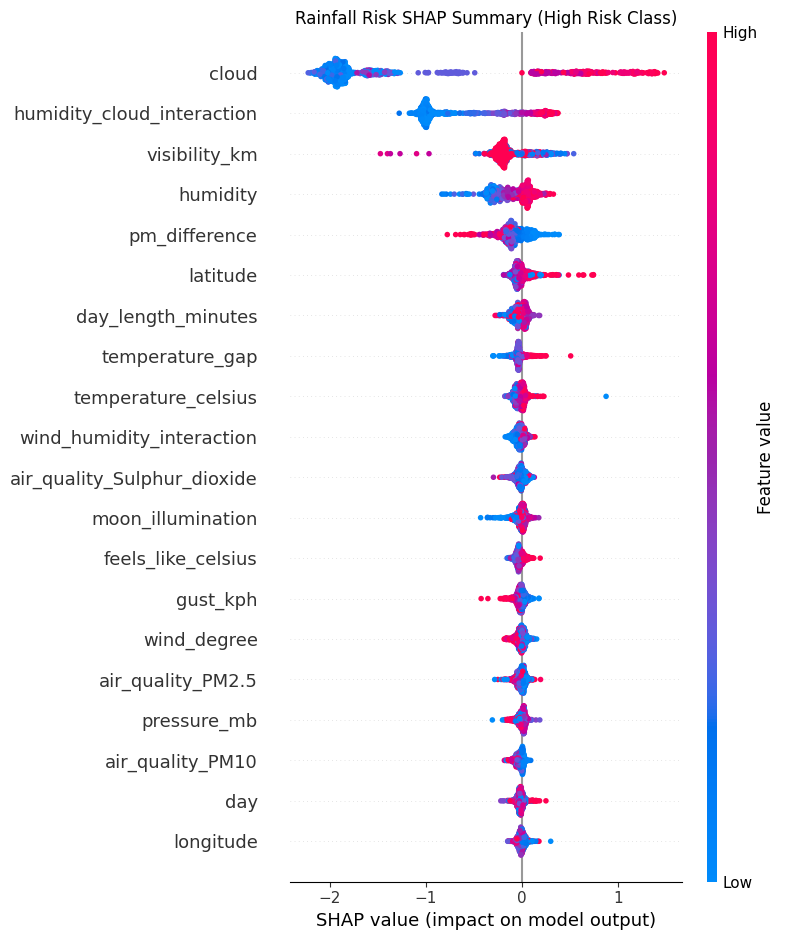

In [5]:

import shap
import matplotlib.pyplot as plt
shap.summary_plot(
    rainfall_shap_values[:, :, 2],
    X_rainfall_sample,
    show=False
)
plt.title(
    "Rainfall Risk SHAP Summary (High Risk Class)"
)
plt.tight_layout()
plt.show()


# Expected Insights


In [6]:
import numpy as np
importance = np.abs(
    rainfall_shap_values[:, :, 2]
).mean(axis=0)
top_features = (
    pd.DataFrame({
        "Feature": X_rainfall_sample.columns,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)
print(top_features.head(20))


                        Feature  Importance
7                         cloud    1.543410
31   humidity_cloud_interaction    0.718758
9                 visibility_km    0.195178
6                      humidity    0.165642
28                pm_difference    0.124549
0                      latitude    0.062482
26           day_length_minutes    0.052600
27              temperature_gap    0.051514
2           temperature_celsius    0.040888
30    wind_humidity_interaction    0.038136
15  air_quality_Sulphur_dioxide    0.036884
20            moon_illumination    0.036442
8            feels_like_celsius    0.035619
11                     gust_kph    0.033725
4                   wind_degree    0.032980
16            air_quality_PM2.5    0.032387
5                   pressure_mb    0.030950
17             air_quality_PM10    0.030621
23                          day    0.028714
1                     longitude    0.027437


# HEATWAVE GLOBAL SHAP

In [7]:

importance = abs(
    heatwave_shap_values[:, :, 0]
).mean(axis=0)
top_features = (
    pd.DataFrame({
        "Feature": X_heatwave_sample.columns,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)
print(top_features.head(20))



                         Feature  Importance
2            temperature_celsius    3.738175
31                heatwave_index    0.909664
7                       humidity    0.785106
0                       latitude    0.181357
5                    pressure_mb    0.115175
29     wind_humidity_interaction    0.093171
1                      longitude    0.088639
26            day_length_minutes    0.083269
13             air_quality_Ozone    0.081614
9                  visibility_km    0.077844
30    humidity_cloud_interaction    0.076883
27                 pm_difference    0.049739
11                      gust_kph    0.047343
20             moon_illumination    0.041733
4                    wind_degree    0.040911
14  air_quality_Nitrogen_dioxide    0.037888
17              air_quality_PM10    0.036842
22                         month    0.036477
15   air_quality_Sulphur_dioxide    0.031968
48                     region_17    0.027174


# SINGLE PREDICTION EXPLANATION

In [8]:

sample_index = 0
rainfall_prediction = rainfall_model.predict(
    X_rainfall_sample.iloc[[sample_index]]
)
print(
    "Predicted Rainfall Class:",
    rainfall_prediction[0]
)
shap_values_single = rainfall_explainer.shap_values(
    X_rainfall_sample.iloc[[sample_index]]
)
print(
    "SHAP Shape:",
    shap_values_single.shape
)


Predicted Rainfall Class: 1
SHAP Shape: (1, 94, 3)


# TOP CONTRIBUTORS FOR THIS PREDICTION

In [9]:

import pandas as pd
import numpy as np
class_index = rainfall_prediction[0]
local_importance = pd.DataFrame({
    "Feature": X_rainfall_sample.columns,
    "SHAP_Value": shap_values_single[0, :, class_index]
})
local_importance["Absolute_SHAP"] = (
    local_importance["SHAP_Value"]
    .abs()
)
local_importance = (
    local_importance
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
)
print(
    local_importance[
        ["Feature", "SHAP_Value"]
    ].head(15)
)


                        Feature  SHAP_Value
7                         cloud    2.392687
31   humidity_cloud_interaction    1.131274
9                 visibility_km    0.367405
12  air_quality_Carbon_Monoxide   -0.126866
28                pm_difference    0.104731
27              temperature_gap    0.067415
13            air_quality_Ozone   -0.054665
0                      latitude    0.046011
6                      humidity    0.044925
29          pollution_intensity   -0.040492
24                         hour   -0.036522
15  air_quality_Sulphur_dioxide   -0.030535
1                     longitude    0.023211
17             air_quality_PM10    0.022357
22                        month   -0.022126
